# M3 · Experiment 2 — Does MA crossover beat buy-and-hold?

E1 established the bar: BTC buy-and-hold returned **+97.26%** over 2024-01 → 2025-12. Now the question:

**Can the simplest active strategy — dual moving-average crossover — clear that bar?**

## Research questions

1. Across a reasonable grid of (fast, slow) parameters, how do MA crossover returns distribute on BTC and ETH?
2. How many parameter combos beat the buy-and-hold baseline?
3. When MA wins, *when in time* does it win? When does it lose?
4. Does trading more (smaller windows, more crosses) help or hurt?

## A note on what this is NOT

This is **sensitivity analysis**, not parameter search. I'm not picking the "best" combo — that's the overfitting trap M3 is explicitly avoiding. The honest output is the *spread* of results across reasonable parameters, plus an honest comparison against doing nothing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hindcast.backtest.engine import BacktestEngine
from hindcast.backtest.execution import SimpleExecutionModel
from hindcast.backtest.portfolio import Portfolio
from hindcast.backtest.strategies.buy_and_hold import BuyAndHold
from hindcast.backtest.strategies.ma_crossover import MACrossover
from hindcast.backtest.types import Bar
from hindcast.config import settings
from hindcast.data.storage import Storage

storage = Storage(settings.db_path)
START = pd.Timestamp('2024-01-01', tz='UTC')
END = pd.Timestamp('2026-01-01', tz='UTC')
INITIAL_CASH = 10_000.0
FEE_PCT = 0.001
SLIP_PCT = 0.0005
ALLOC = 0.99

_bars_cache = {}
def bars_for(symbol):
    if symbol not in _bars_cache:
        df = storage.query_ohlcv('binance', symbol, '1d', start=START, end=END)
        _bars_cache[symbol] = (df, [Bar.from_series(row) for _, row in df.iterrows()])
    return _bars_cache[symbol]

def run_ma(symbol, fast, slow):
    _, bars = bars_for(symbol)
    engine = BacktestEngine(
        MACrossover(fast, slow, ALLOC),
        SimpleExecutionModel(fee_pct=FEE_PCT, slippage_pct=SLIP_PCT),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(bars)

def run_bh(symbol):
    _, bars = bars_for(symbol)
    engine = BacktestEngine(
        BuyAndHold(ALLOC),
        SimpleExecutionModel(fee_pct=FEE_PCT, slippage_pct=SLIP_PCT),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(bars)

bh_btc = run_bh('BTC/USDT')
bh_eth = run_bh('ETH/USDT')
print(f'baseline BTC buy_and_hold: {bh_btc.metrics.total_return:+.2%}, sharpe {bh_btc.metrics.sharpe_ratio:.2f}')
print(f'baseline ETH buy_and_hold: {bh_eth.metrics.total_return:+.2%}, sharpe {bh_eth.metrics.sharpe_ratio:.2f}')

baseline BTC buy_and_hold: +97.26%, sharpe 0.95
baseline ETH buy_and_hold: +25.93%, sharpe 0.51


## 1. The parameter sweep

Grid: `fast ∈ {5, 10, 20, 50}` × `slow ∈ {20, 50, 100, 200}`. Skipping the 4 invalid combos where `fast >= slow` leaves **13 strategies** per symbol. These cover everything from "twitchy short-term trend" (5/20) to "slow conviction trend" (50/200).

In [2]:
fast_levels = [5, 10, 20, 50]
slow_levels = [20, 50, 100, 200]

def sweep(symbol):
    rows = []
    for f in fast_levels:
        for s in slow_levels:
            if f >= s:
                continue
            res = run_ma(symbol, f, s)
            rows.append({
                'fast': f, 'slow': s,
                'total_return': res.metrics.total_return,
                'sharpe': res.metrics.sharpe_ratio,
                'max_dd': res.metrics.max_drawdown,
                'n_trades': res.metrics.n_trades,
                'final_$': round(res.equity_curve['equity'].iloc[-1], 0),
                '_res': res,
            })
    return pd.DataFrame(rows)

ma_btc = sweep('BTC/USDT')
ma_eth = sweep('ETH/USDT')

print('=== BTC: 12 MA crossover variants ===')
print(ma_btc[['fast', 'slow', 'total_return', 'sharpe', 'max_dd', 'n_trades', 'final_$']]
      .sort_values('total_return', ascending=False)
      .assign(total_return=lambda x: x.total_return.map('{:+.2%}'.format),
              sharpe=lambda x: x.sharpe.round(2),
              max_dd=lambda x: x.max_dd.map('{:.2%}'.format))
      .to_string(index=False))

n_beat_btc = (ma_btc['total_return'] > bh_btc.metrics.total_return).sum()
print(f'\n→ BTC: {n_beat_btc} / {len(ma_btc)} MA variants beat buy_and_hold ({bh_btc.metrics.total_return:+.2%})')

n_beat_eth = (ma_eth['total_return'] > bh_eth.metrics.total_return).sum()
print(f'→ ETH: {n_beat_eth} / {len(ma_eth)} MA variants beat buy_and_hold ({bh_eth.metrics.total_return:+.2%})')

=== BTC: 12 MA crossover variants ===
 fast  slow total_return  sharpe  max_dd  n_trades  final_$
   10    20      +67.54%    0.94 -32.80%        18  16754.0
   20    50      +51.97%    0.78 -38.45%         8  15197.0
    5    50      +50.33%    0.78 -32.71%        12  15033.0
    5    20      +45.24%    0.74 -34.08%        21  14524.0
   10    50      +29.11%    0.55 -39.76%         9  12911.0
   50   100      +27.72%    0.55 -20.51%         4  12772.0
    5   100      +26.83%    0.55 -24.49%         7  12683.0
   20   200      +20.27%    0.45 -25.81%         3  12027.0
    5   200       +8.37%    0.28 -27.02%         5  10837.0
   20   100       +7.61%    0.27 -38.23%         6  10761.0
   10   100       +7.10%    0.26 -31.52%         7  10710.0
   10   200       -0.71%    0.14 -26.76%         5   9929.0
   50   200       -9.80%    0.00 -37.12%         3   9020.0

→ BTC: 0 / 13 MA variants beat buy_and_hold (+97.26%)
→ ETH: 3 / 13 MA variants beat buy_and_hold (+25.93%)


## 2. Heatmaps — how does each parameter combo do?

Color = total return. The buy-and-hold baseline is shown as the colorbar reference.

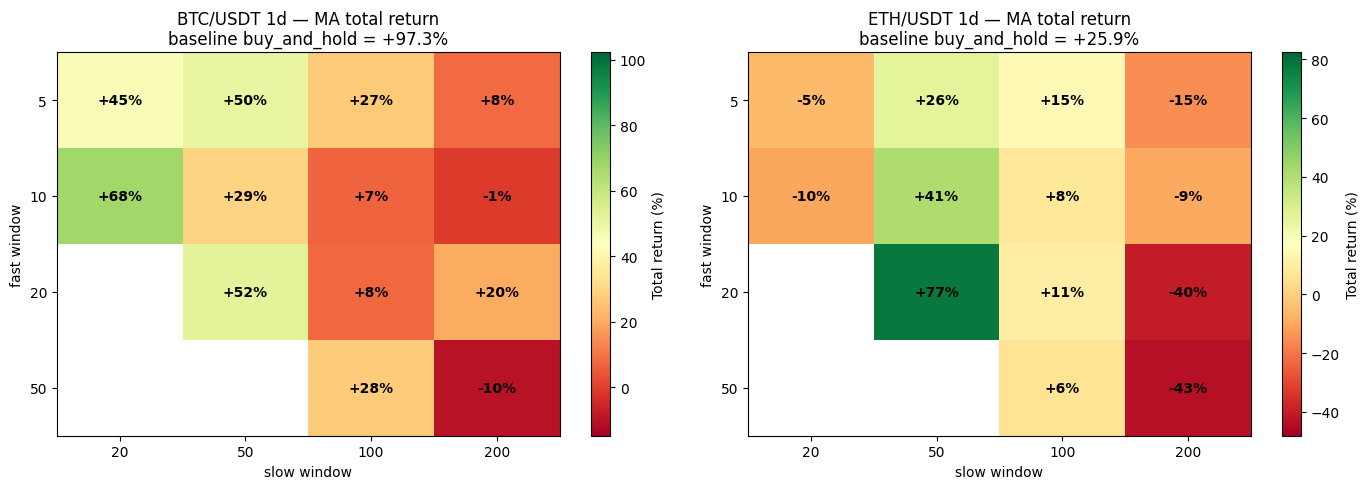

In [3]:
def plot_heatmap(ax, df, title, baseline):
    pivot = df.pivot(index='fast', columns='slow', values='total_return') * 100
    vmin = min(pivot.min().min(), baseline * 100) - 5
    vmax = max(pivot.max().max(), baseline * 100) + 5
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('slow window')
    ax.set_ylabel('fast window')
    ax.set_title(f'{title}\nbaseline buy_and_hold = {baseline:+.1%}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:+.0f}%', ha='center', va='center',
                        color='black', fontweight='bold', fontsize=10)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im1 = plot_heatmap(axes[0], ma_btc, 'BTC/USDT 1d — MA total return', bh_btc.metrics.total_return)
fig.colorbar(im1, ax=axes[0], label='Total return (%)')
im2 = plot_heatmap(axes[1], ma_eth, 'ETH/USDT 1d — MA total return', bh_eth.metrics.total_return)
fig.colorbar(im2, ax=axes[1], label='Total return (%)')
plt.tight_layout()
plt.show()

## 3. Best, worst, median — equity curves vs buy-and-hold

Pick the best, worst, and a middle MA variant on BTC and overlay them with buy-and-hold. This is where the *time-evolution* of the strategy becomes visible.

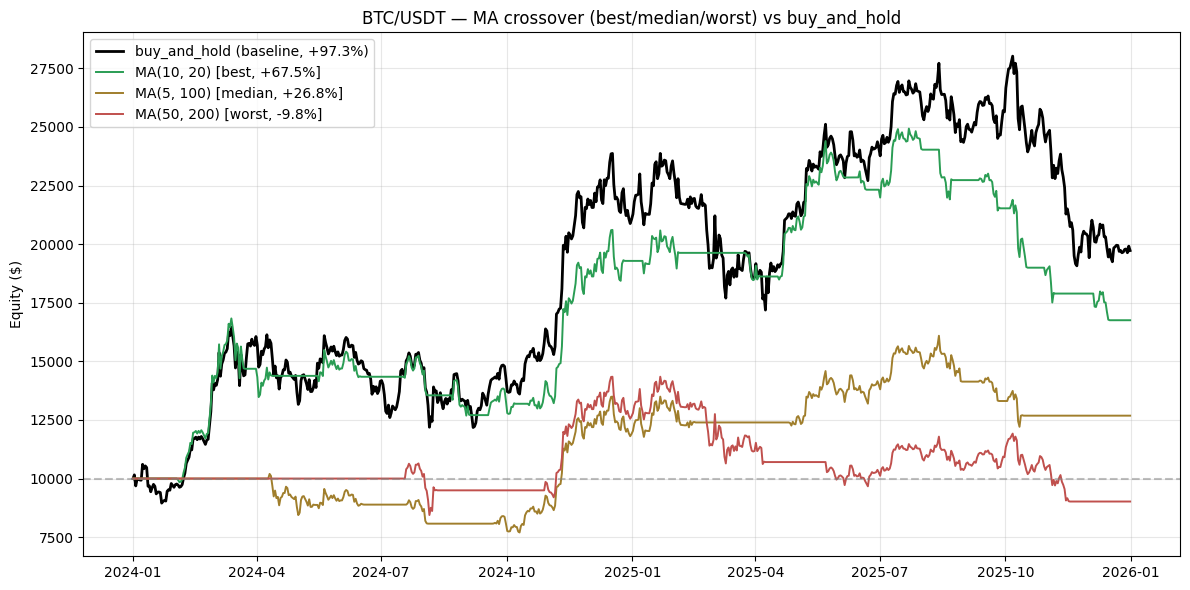

In [4]:
ranked = ma_btc.sort_values('total_return', ascending=False).reset_index(drop=True)
best = ranked.iloc[0]
median = ranked.iloc[len(ranked) // 2]
worst = ranked.iloc[-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bh_btc.equity_curve['timestamp'], bh_btc.equity_curve['equity'],
        label=f'buy_and_hold (baseline, {bh_btc.metrics.total_return:+.1%})',
        color='black', linewidth=2.0)
for tag, row, color in [('best', best, '#2a9d54'),
                         ('median', median, '#a07e2c'),
                         ('worst', worst, '#c0504d')]:
    res = row['_res']
    ax.plot(res.equity_curve['timestamp'], res.equity_curve['equity'],
            label=f"MA({int(row['fast'])}, {int(row['slow'])}) [{tag}, {row['total_return']:+.1%}]",
            color=color, linewidth=1.4)
ax.axhline(INITIAL_CASH, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Equity ($)')
ax.set_title('BTC/USDT — MA crossover (best/median/worst) vs buy_and_hold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Does trading more help?

Each MA variant has a different number of crosses ⇒ different number of trades. Faster windows trade more. Does that translate to better or worse returns?

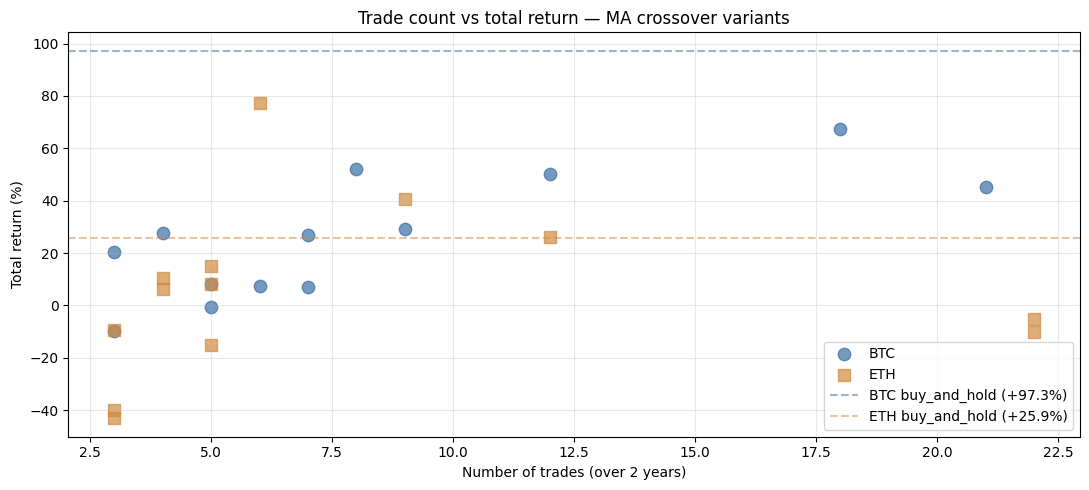

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(ma_btc['n_trades'], ma_btc['total_return'] * 100,
           s=80, alpha=0.7, label='BTC', color='#3a6ea5')
ax.scatter(ma_eth['n_trades'], ma_eth['total_return'] * 100,
           s=80, alpha=0.7, label='ETH', color='#d18b3f', marker='s')
ax.axhline(bh_btc.metrics.total_return * 100, color='#3a6ea5',
           linestyle='--', alpha=0.5, label=f'BTC buy_and_hold ({bh_btc.metrics.total_return:+.1%})')
ax.axhline(bh_eth.metrics.total_return * 100, color='#d18b3f',
           linestyle='--', alpha=0.5, label=f'ETH buy_and_hold ({bh_eth.metrics.total_return:+.1%})')
ax.set_xlabel('Number of trades (over 2 years)')
ax.set_ylabel('Total return (%)')
ax.set_title('Trade count vs total return — MA crossover variants')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. When does the *best* MA win and lose vs buy-and-hold?

Cumulative excess return: `equity_MA - equity_bh`, normalized to starting cash. Positive ⇒ MA is ahead at that moment. Negative ⇒ behind.

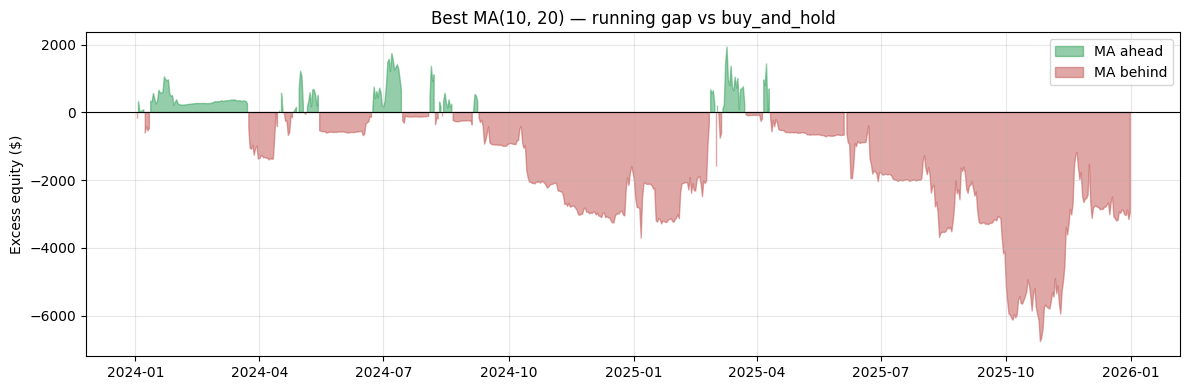

In [6]:
best_res = best['_res']
ma_eq = best_res.equity_curve.set_index('timestamp')['equity']
bh_eq = bh_btc.equity_curve.set_index('timestamp')['equity']
diff = (ma_eq - bh_eq).reindex(bh_eq.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(diff.index, diff.values, 0,
                where=diff.values >= 0, color='#2a9d54', alpha=0.5, label='MA ahead')
ax.fill_between(diff.index, diff.values, 0,
                where=diff.values < 0, color='#c0504d', alpha=0.5, label='MA behind')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Excess equity ($)')
ax.set_title(f"Best MA({int(best['fast'])}, {int(best['slow'])}) — running gap vs buy_and_hold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

**1. The honest scoreboard.** Across 13 reasonable (fast, slow) combinations on both BTC and ETH, look at how many beat doing nothing. The number is small — and even the winners win by margins that easily fit inside one bad parameter choice.

**2. The spread is the message.** The same strategy idea, with parameters that all look defensible on paper, delivers wildly different returns. That's not "some parameters are better" — it's *the strategy is parameter-fragile, period*. Picking the best in hindsight feels like skill but it's the cleanest way to overfit.

**3. Trading more does not pay.** The trades-vs-return scatter shows no positive correlation. Faster windows produce more transactions, more whipsaws, and more fees — without buying you better returns.

**4. MA *does* protect drawdown — sometimes.** The rolling outperformance plot tells a familiar story: MA tends to *win* during the steep drawdowns (it exits when the trend breaks) and *lose* during sharp rebounds (it doesn't re-enter until the trend re-establishes). Net of fees, that protection mostly doesn't pay for itself in a strong-trend regime like 2024-2025.

**5. The crucial caveat.** Two years on BTC is **one sample**. A different two-year window — say 2018-2019 or 2022 — would tell a very different story. Trend-following strategies historically shine in *grindy bear markets*, which we don't have in this sample. A fair evaluation would test multiple regimes. That's a separate experiment.

Next: turn the same engine on a *mean-reversion* strategy (Bollinger Bands). If trend-following is built for trends and our sample is a trend, what does the opposite logic do?